# EDA

## Import Libraries & Load Data

In [2]:
# transformation
import pandas as pd

# viz
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
locations = pd.read_csv('data/olist_geolocation_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
categories = pd.read_csv('data/product_category_name_translation.csv')

## Styling

In [4]:
# set seaborn theme
sns.set_theme(context='notebook', style='darkgrid', palette='colorblind')
plt.rcParams.update({
    'figure.figsize': (15, 10),
    'axes.linewidth': 0,
    'patch.linewidth': 0,
})

## Customers

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [7]:
customers.duplicated().sum()

np.int64(0)

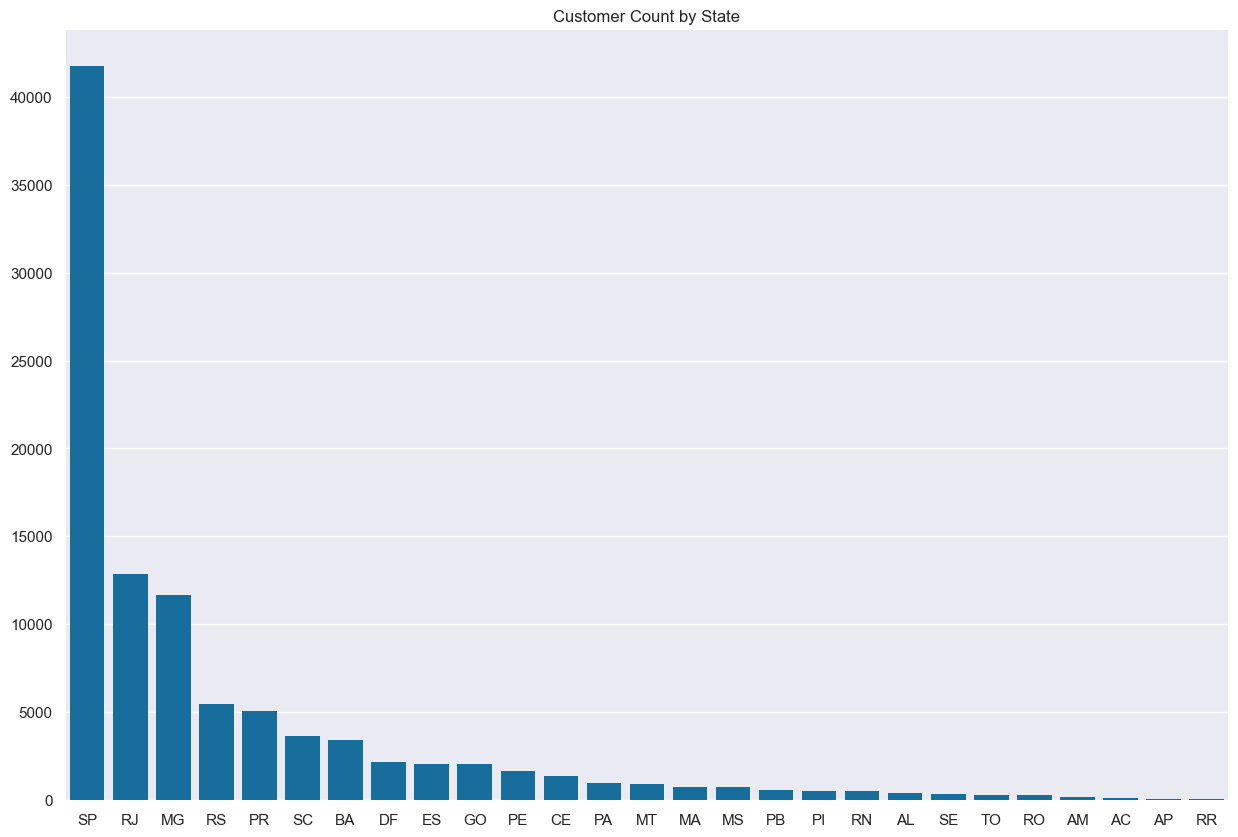

In [8]:
customer_state_freq = customers['customer_state'].value_counts()

# plot
sns.countplot(
    data=customers, 
    x='customer_state', 
    order=customer_state_freq.index,
)

# title and labels
plt.title('Customer Count by State')
plt.xlabel('')
plt.ylabel('');

## Locations

In [9]:
locations.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [10]:
locations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [11]:
locations.duplicated().sum()

np.int64(261831)

In [12]:
locations = locations.drop_duplicates()
locations.shape

(738332, 5)

In [13]:
# check if zip code prefixes are unique
locations['geolocation_zip_code_prefix'].nunique() == len(locations)  

False

In [ ]:
# make them unique by averaging lat and lng for each zip code prefix
locations = (
    locations.groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': 'first',
        'geolocation_state': 'first'
    })
    .reset_index()
)

locations.shape

(19015, 5)

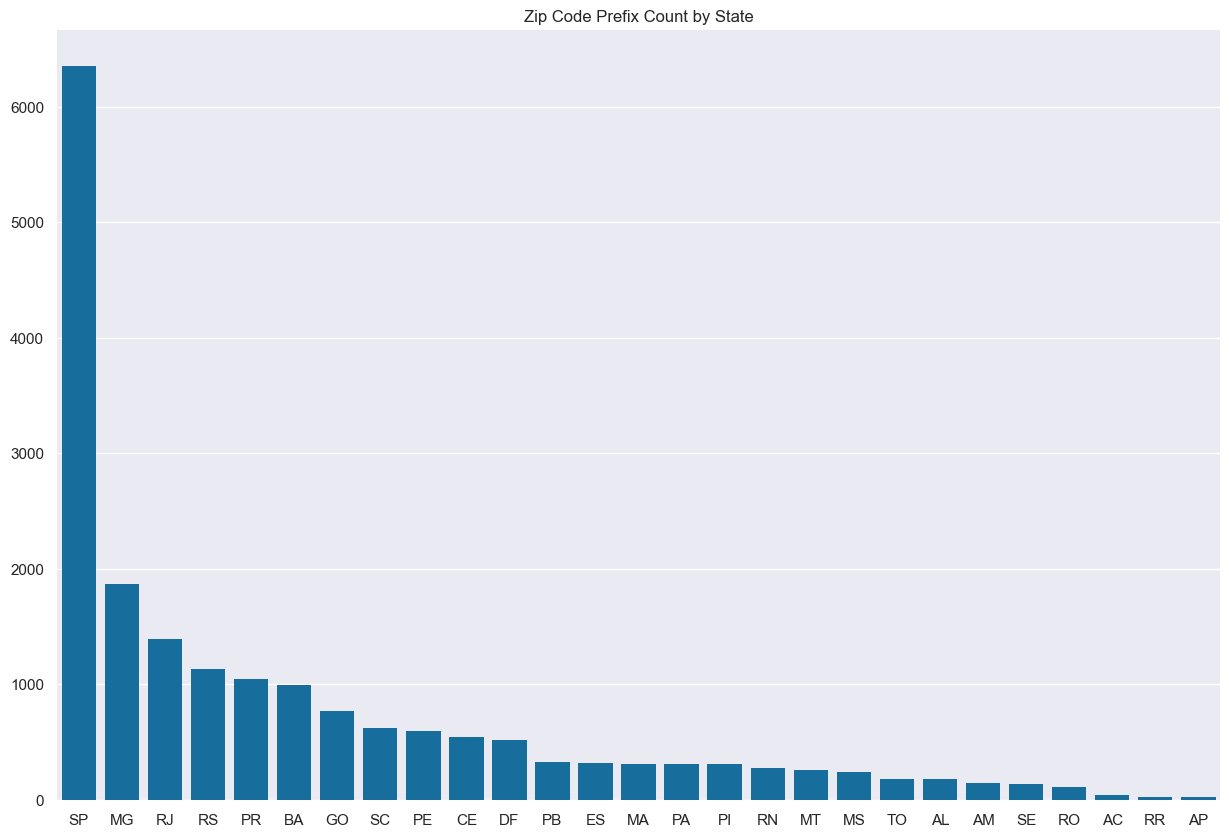

In [15]:
zip_state_freq = locations['geolocation_state'].value_counts()

# plot
sns.countplot(
    data=locations, 
    x='geolocation_state', 
    order=zip_state_freq.index,
)

# title and labels
plt.title('Zip Code Prefix Count by State')
plt.xlabel('')
plt.ylabel('');

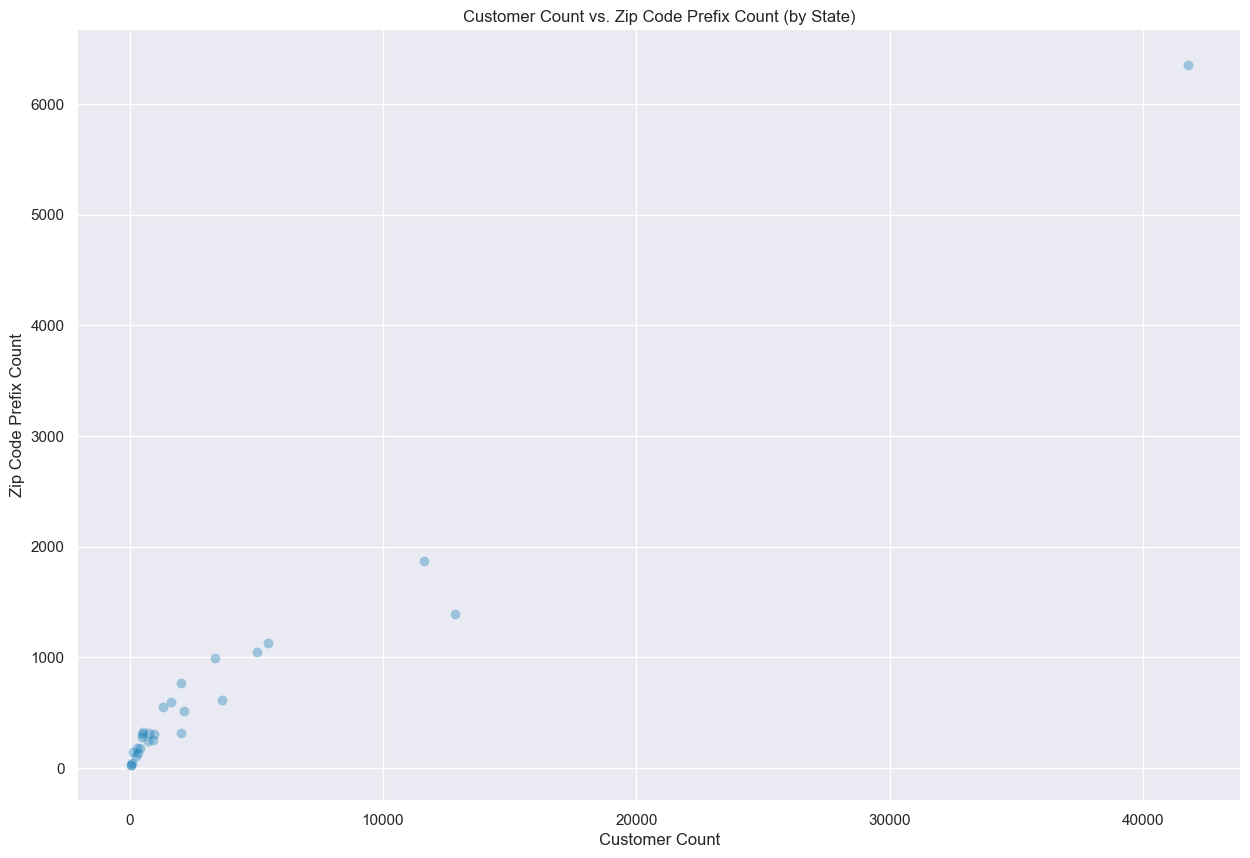

In [16]:
# for comparing customer count vs. zip code prefix count per state
state_comparison = pd.DataFrame({
    'customer_freq': customer_state_freq,
    'zip_freq': zip_state_freq
})

# plot
sns.scatterplot(
    data=state_comparison, 
    x='customer_freq',
    y='zip_freq', 
    s=50,
    alpha=0.33,
    linewidth=0
)

# titles and labels
plt.title('Customer Count vs. Zip Code Prefix Count (by State)')
plt.xlabel('Customer Count')
plt.ylabel('Zip Code Prefix Count');

## Items

In [17]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [18]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [19]:
items.duplicated().sum()

np.int64(0)

In [20]:
# convert to datetime
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [21]:
# check is shipping_limit_date applies to orders or individual items
items.groupby('order_id')['shipping_limit_date'].nunique().value_counts()

shipping_limit_date
1    98330
2      325
3       11
Name: count, dtype: int64

## Payments

In [22]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [23]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [24]:
payments.duplicated().sum()

np.int64(0)

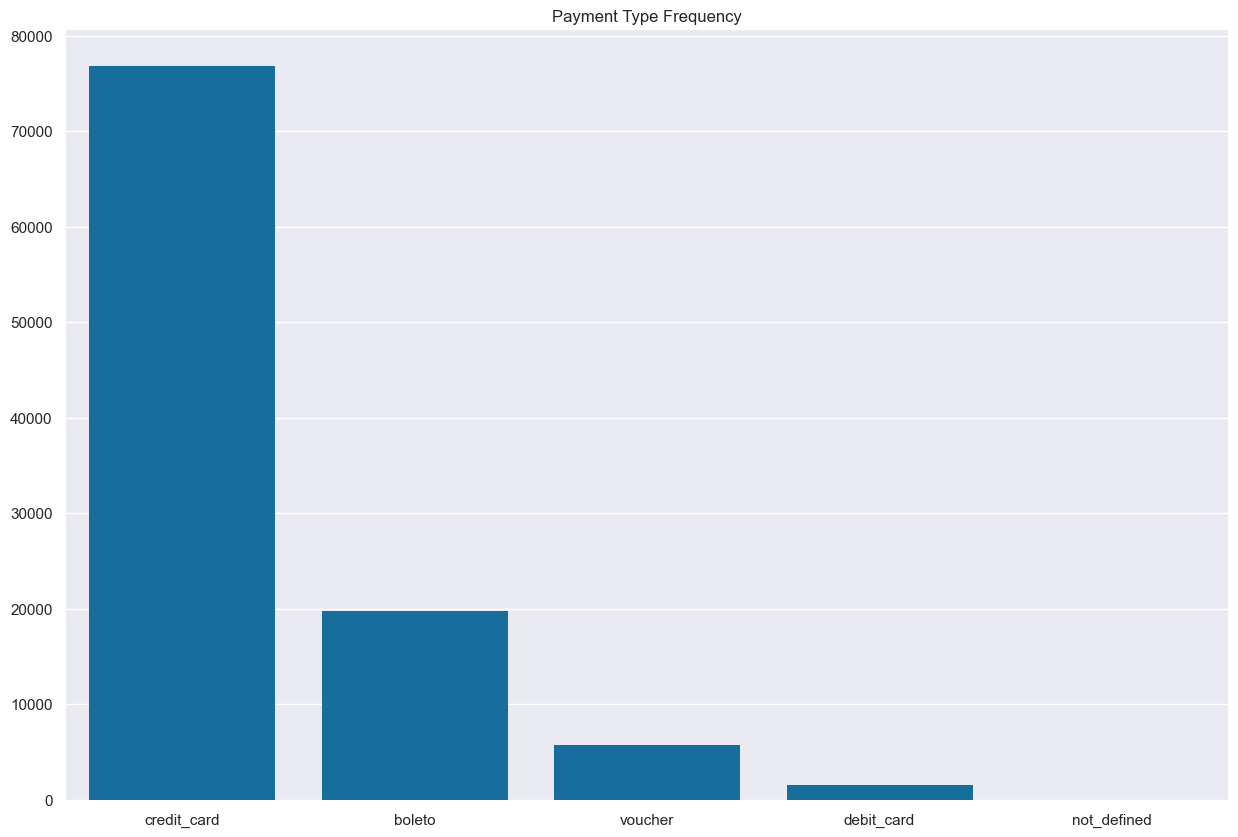

In [25]:
# plot payment type frequency
payment_type_freq = payments['payment_type'].value_counts()

# plot
sns.countplot(
    data=payments, 
    x='payment_type', 
    order=payment_type_freq.index,
)

# title and labels
plt.title('Payment Type Frequency')
plt.xlabel('')
plt.ylabel('');

In [26]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [27]:
# drop rows with undefined payment type
payments = payments[payments['payment_type'] != 'not_defined']

payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: count, dtype: int64

## Orders

In [28]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [29]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [30]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [31]:
orders = orders.dropna(subset=['order_delivered_carrier_date', 'order_delivered_customer_date'])

orders.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [32]:
orders.duplicated().sum()

np.int64(0)

In [33]:
orders['order_status'].value_counts()

order_status
delivered    96469
canceled         6
Name: count, dtype: int64

In [34]:
# drop canceled orders
orders = orders[orders['order_status'] != 'canceled']

In [35]:
# convert date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.DataFrame'>
Index: 96469 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96469 non-null  str           
 1   customer_id                    96469 non-null  str           
 2   order_status                   96469 non-null  str           
 3   order_purchase_timestamp       96469 non-null  datetime64[us]
 4   order_approved_at              96455 non-null  datetime64[us]
 5   order_delivered_carrier_date   96469 non-null  datetime64[us]
 6   order_delivered_customer_date  96469 non-null  datetime64[us]
 7   order_estimated_delivery_date  96469 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.6 MB


In [36]:
# calculate arrival delta: actual - estimated
orders['arrival_delta'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late_arrival'] = orders['arrival_delta'] > 0

orders['arrival_delta'].describe()

count    96469.000000
mean       -11.876074
std         10.181995
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: arrival_delta, dtype: float64

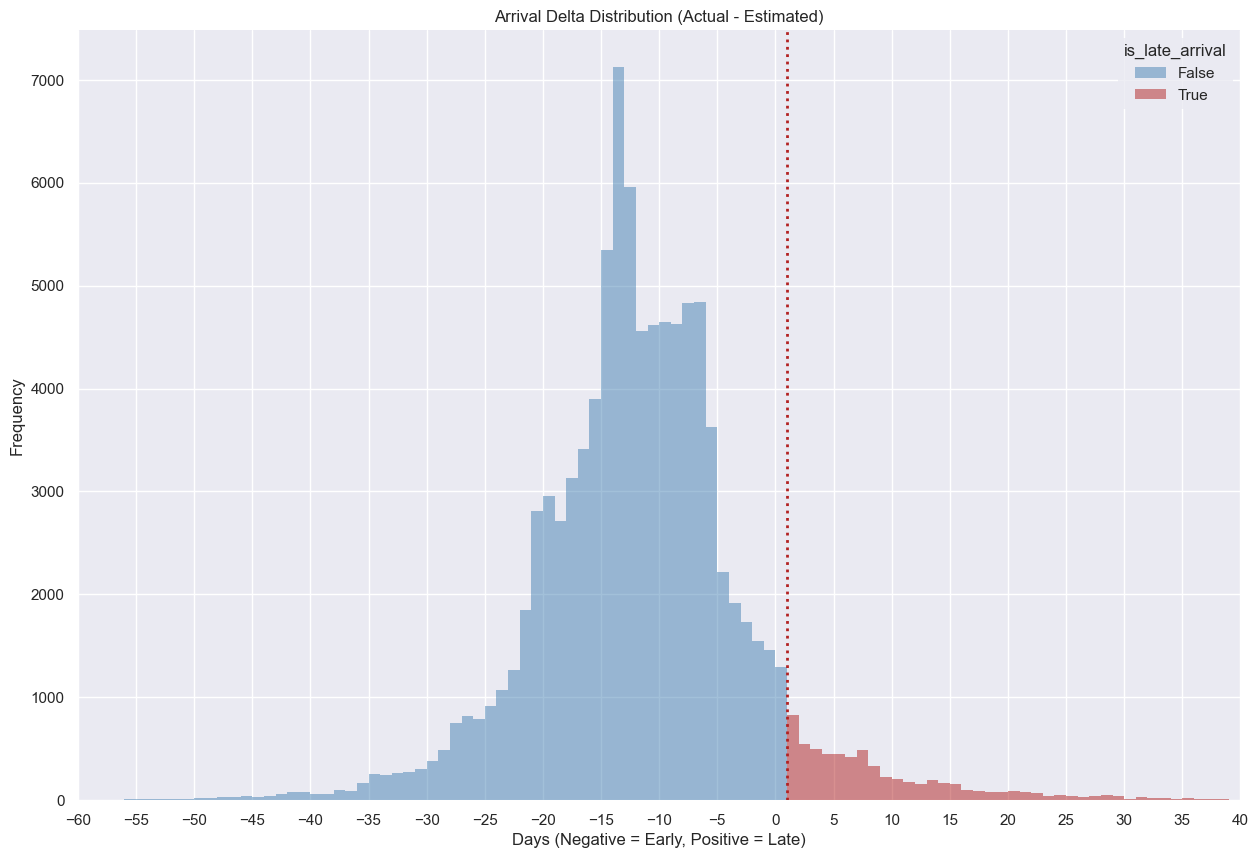

In [37]:
# plot
sns.histplot(
    data=orders,
    x='arrival_delta',
    binwidth=1,
    hue='is_late_arrival',
    palette={True: 'firebrick', False: 'steelblue'},
)

# titles and labels
plt.title('Arrival Delta Distribution (Actual - Estimated)')
plt.xlabel('Days (Negative = Early, Positive = Late)')
plt.ylabel('Frequency')
plt.xlim(-60, 40)
plt.xticks(range(-60, 41, 5))

# vertical line to separate early from late
plt.axvline(1, color='firebrick', linestyle=':', linewidth=2);

In [38]:
# calculate departure delta: order_delivered_carrier_date - shipping_limit_date
items = items.merge(orders[['order_id', 'order_delivered_carrier_date']], on='order_id')
items['departure_delta'] = (items['order_delivered_carrier_date'] - items['shipping_limit_date']).dt.days
items['is_late_departure'] = items['departure_delta'] > 0

items['departure_delta'].describe()


count    110188.000000
mean         -3.822004
std           5.832116
min       -1047.000000
25%          -6.000000
50%          -4.000000
75%          -2.000000
max         116.000000
Name: departure_delta, dtype: float64

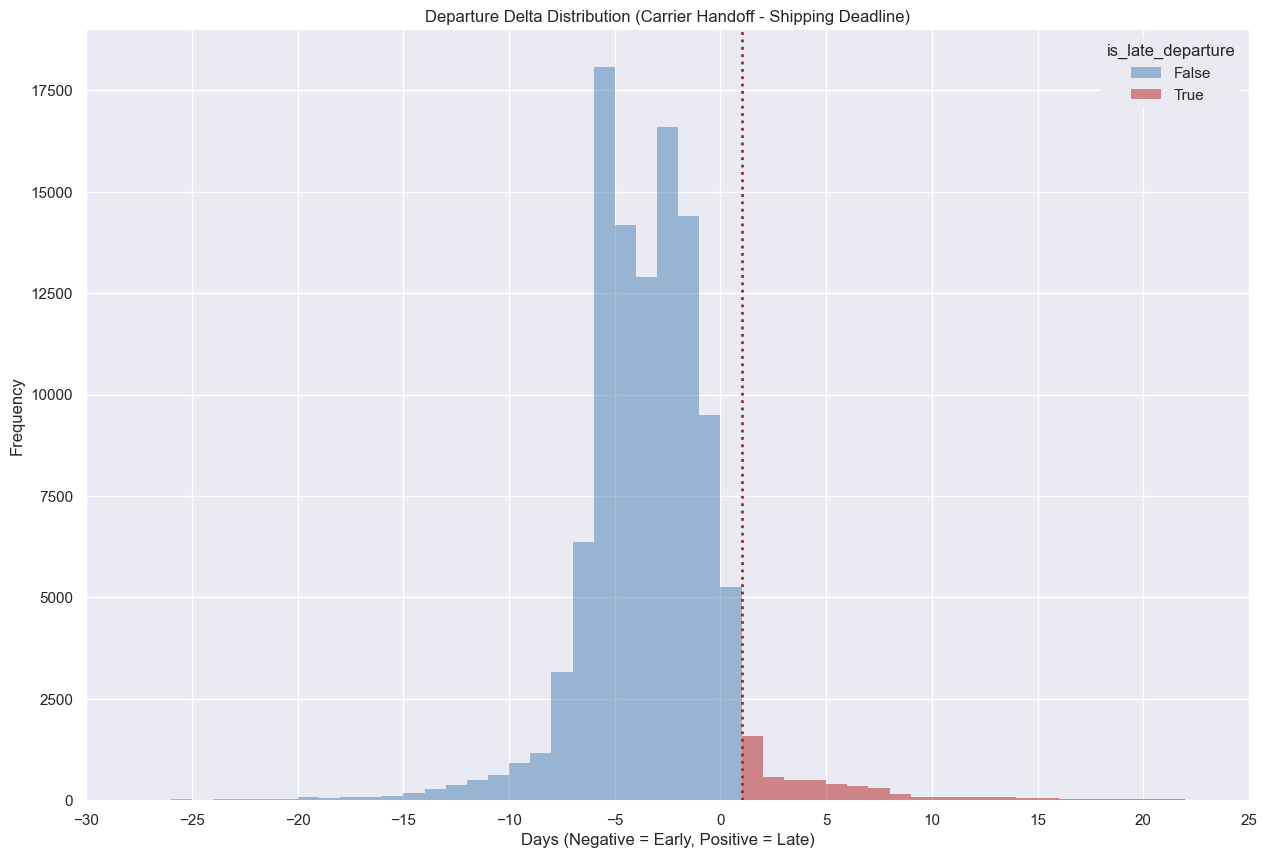

In [39]:
# plot
sns.histplot(
    data=items,
    x='departure_delta',
    binwidth=1,
    hue='is_late_departure',
    palette={True: 'firebrick', False: 'steelblue'},
)

# titles and labels
plt.title('Departure Delta Distribution (Carrier Handoff - Shipping Deadline)')
plt.xlabel('Days (Negative = Early, Positive = Late)')
plt.ylabel('Frequency')
plt.xlim(-30, 25)
plt.xticks(range(-30, 26, 5))

# vertical line to separate early from late
plt.axvline(1, color='firebrick', linestyle=':', linewidth=2);

This histogram is based on *item* frequency, not *order* frequency, since items in the same order can have different sellers and shipping deadlines.

(-65.0, 65.0)

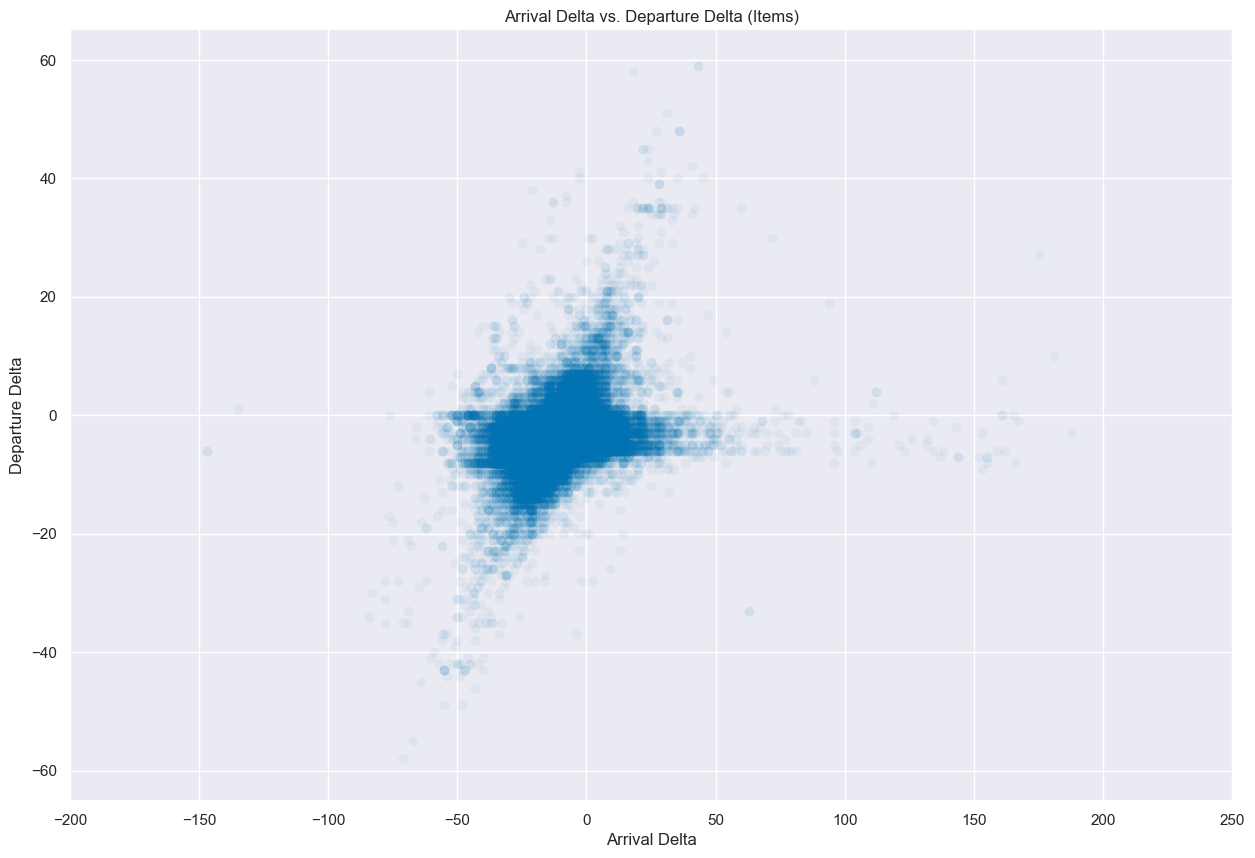

In [40]:
# for comparing departure delta vs. arrival delta
delta_comparison = items.merge(orders, on='order_id')

# plot
sns.scatterplot(
    data=delta_comparison,
    x='arrival_delta', 
    y='departure_delta',
    s=50,
    alpha=0.05,
    linewidth=0,
)

# titles and labels
plt.title('Arrival Delta vs. Departure Delta (Items)')
plt.xlabel('Arrival Delta')
plt.ylabel('Departure Delta')
plt.xlim(-200, 250)
plt.ylim(-65, 65)

(-65.0, 65.0)

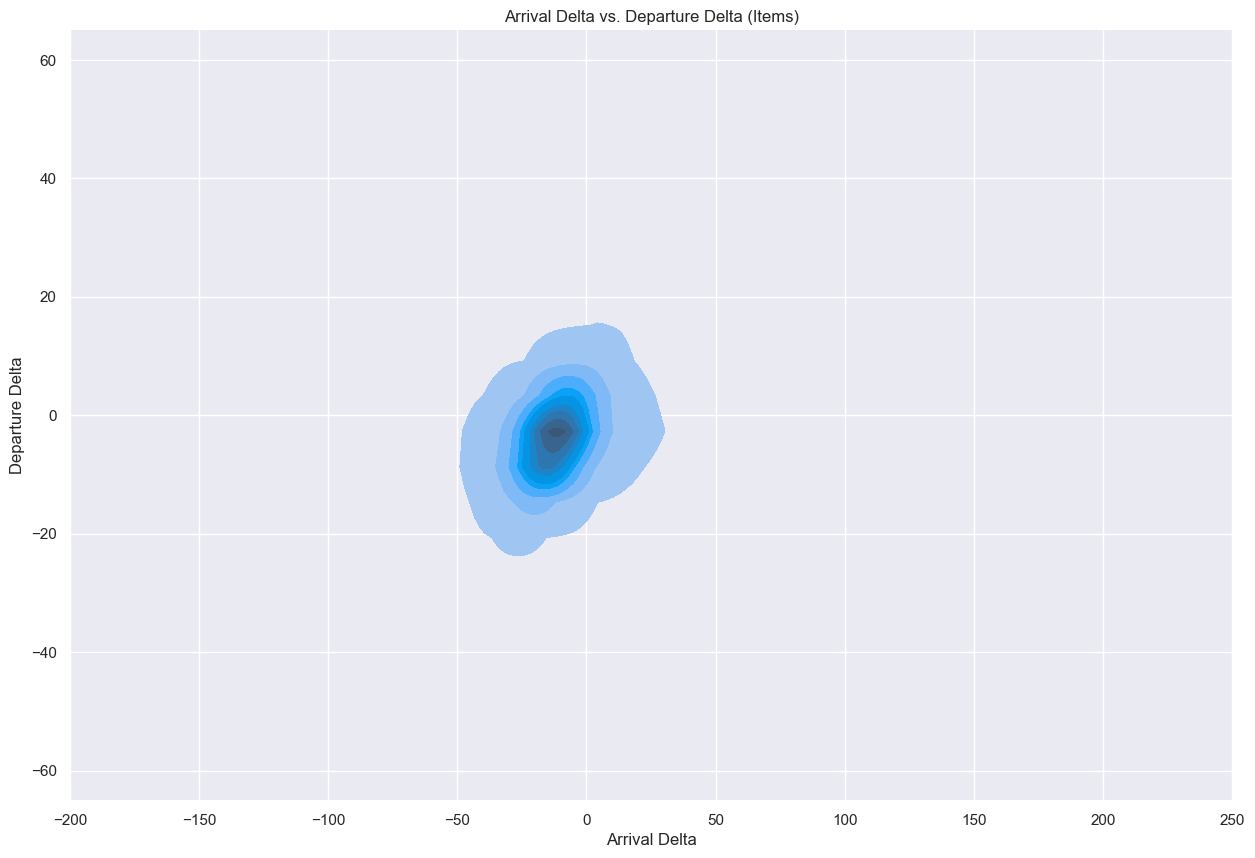

In [ ]:
# # kde plot
# sns.kdeplot(
#     data=delta_comparison, 
#     x='arrival_delta', 
#     y='departure_delta',
#     fill=True,
#     bw_adjust=5,
#     thresh=0.02,
#     gridsize=200
# )

# # titles and labels
# plt.title('Arrival Delta vs. Departure Delta (Items)')
# plt.xlabel('Arrival Delta')
# plt.ylabel('Departure Delta')
# plt.xlim(-200, 250)
# plt.ylim(-65, 65)

98% of items fall into the blob.

## Products

In [42]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [43]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [44]:
products = products.dropna()

In [45]:
products.duplicated().sum()

np.int64(0)

In [46]:
categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [47]:
categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [48]:
products = products.merge(categories, on='product_category_name')
products.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


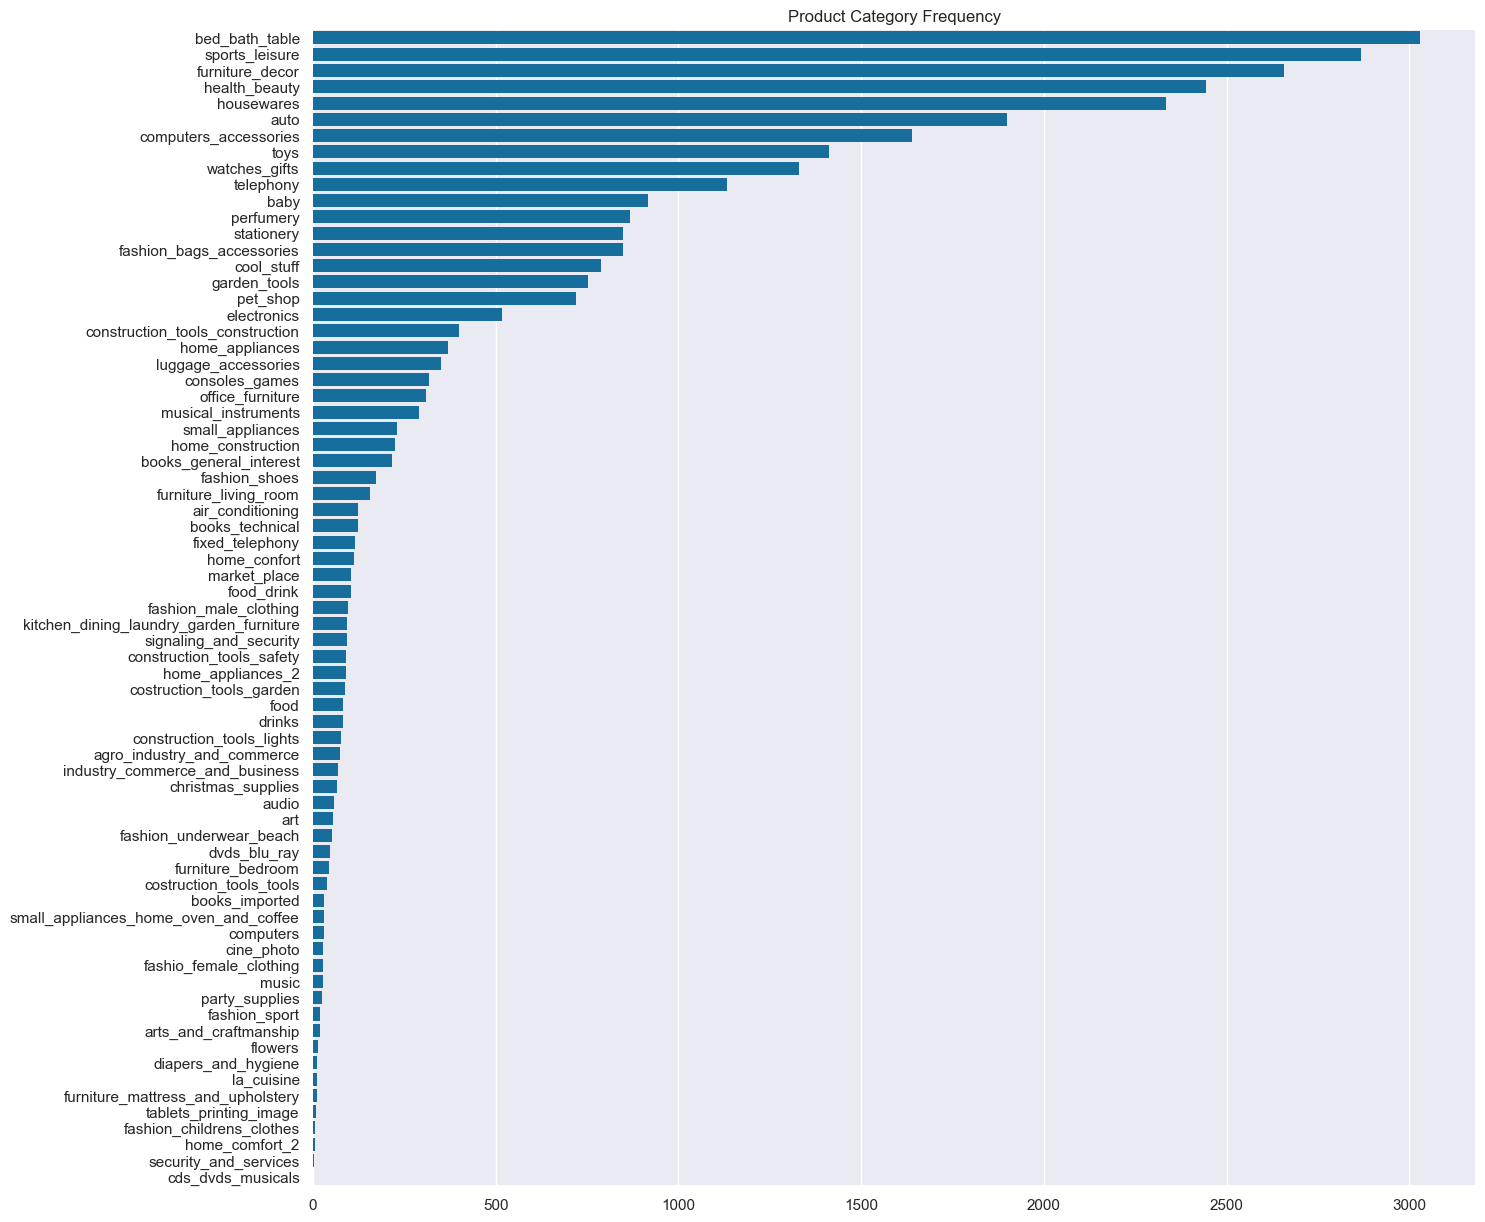

In [49]:
category_freq = products['product_category_name_english'].value_counts()

# plot
ax = plt.figure(figsize=(15, 15))
sns.countplot(
    data=products, 
    y='product_category_name_english', 
    order=category_freq.index,
)

# title and labels
plt.title('Product Category Frequency')
plt.xlabel('')
plt.ylabel('');

## Sellers

In [50]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [51]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [52]:
sellers.duplicated().sum()

np.int64(0)

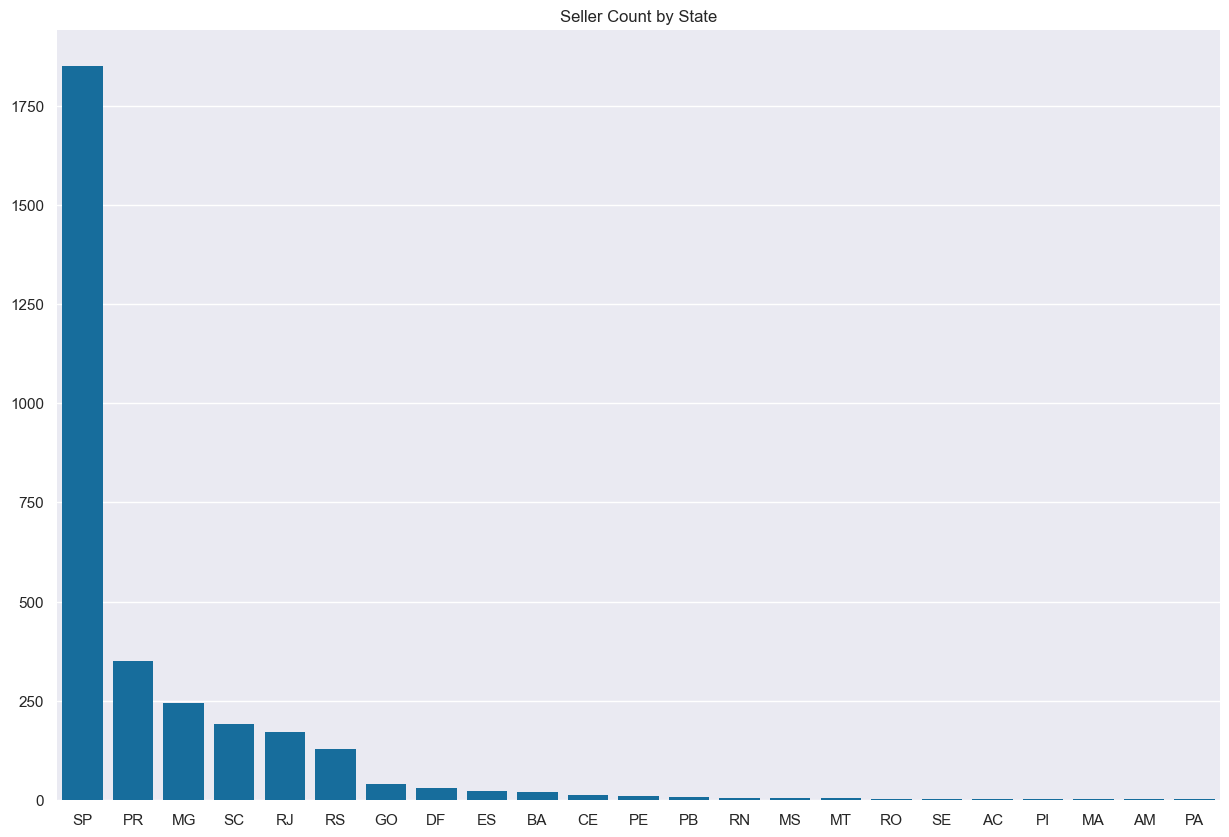

In [53]:
seller_state_freq = sellers['seller_state'].value_counts()

# plot
sns.countplot(
    data=sellers, 
    x='seller_state', 
    order=seller_state_freq.index,
)

# title and labels
plt.title('Seller Count by State')
plt.xlabel('')
plt.ylabel('');

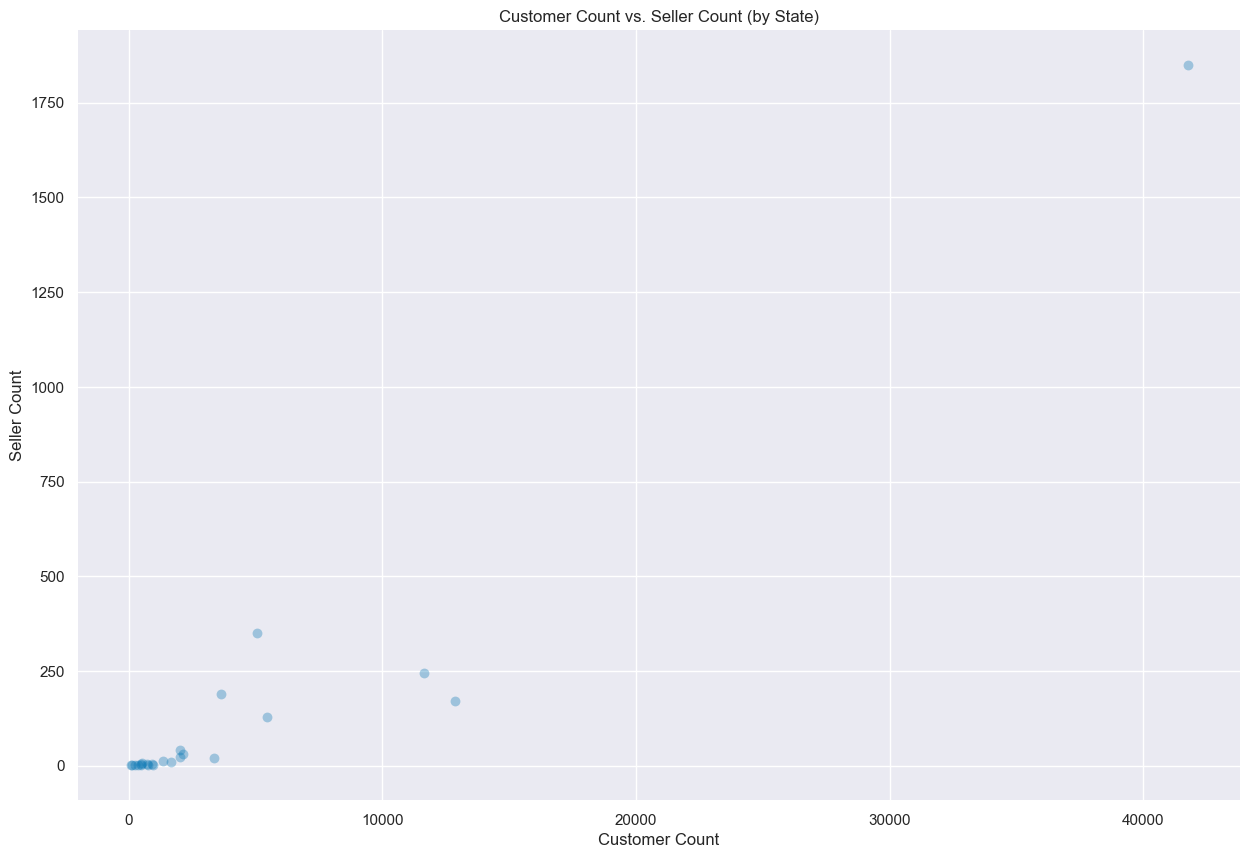

In [54]:
# for comparing customer count vs. seller count per state
state_comparison = pd.DataFrame({
    'customer_freq': customer_state_freq,
    'seller_freq': seller_state_freq
})

# plot
sns.scatterplot(
    data=state_comparison, 
    x='customer_freq',
    y='seller_freq', 
    s=50,
    alpha=0.33,
    linewidth=0
)

# titles and labels
plt.title('Customer Count vs. Seller Count (by State)')
plt.xlabel('Customer Count')
plt.ylabel('Seller Count');

## Export CSV

In [55]:
# merge data
customers = (
    customers.merge(locations, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')
    .rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'})
)

sellers = (
    sellers.merge(locations, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix')
    .rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'})
)

df = (
    orders.merge(customers, on='customer_id')  # each order has a unique customer_id
    .drop(columns=['customer_id', 'order_delivered_carrier_date'])
    .rename(columns={'customer_unique_id': 'customer_id'})  # confusing names
    .merge(payments, on='order_id')
    # merge last due to size increase
    .merge(items, on='order_id')
    .merge(sellers, on='seller_id')
)

In [56]:
df.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'arrival_delta', 'is_late_arrival',
       'customer_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix_x', 'customer_lat',
       'customer_lng', 'geolocation_city_x', 'geolocation_state_x',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'order_delivered_carrier_date', 'departure_delta', 'is_late_departure',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'geolocation_zip_code_prefix_y', 'seller_lat', 'seller_lng',
       'geolocation_city_y', 'geolocation_state_y'],
      dtype='str')

In [58]:
cols_to_keep = [
    'order_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
    'customer_id',
    'customer_lat',
    'customer_lng',
    'seller_id',
    'seller_lat',
    'seller_lng',
    'departure_delta',
    'arrival_delta',
]

df = df[cols_to_keep]
df.head()

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,order_delivered_customer_date,customer_id,customer_lat,customer_lng,seller_id,seller_lat,seller_lng,departure_delta,arrival_delta
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-18,2017-10-10 21:25:13,7c396fd4830fd04220f754e42b4e5bff,-23.577482,-46.587077,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680862,-46.444311,-2,-8
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-18,2017-10-10 21:25:13,7c396fd4830fd04220f754e42b4e5bff,-23.577482,-46.587077,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680862,-46.444311,-2,-8
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-18,2017-10-10 21:25:13,7c396fd4830fd04220f754e42b4e5bff,-23.577482,-46.587077,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680862,-46.444311,-2,-8
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-13,2018-08-07 15:27:45,af07308b275d755c9edb36a90c618231,-12.186877,-44.540232,289cdb325fb7e7f891c38608bf9e0962,-19.807885,-43.980818,-4,-6
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-09-04,2018-08-17 18:06:29,3a653a41f6f9fc3d2a113cf8398680e8,-16.745150,-48.514783,4869f7a5dfa277a7dca6462dcf3b52b2,-21.363473,-48.229588,-5,-18


In [61]:
df.isna().sum()

order_id                          0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      0
order_estimated_delivery_date     0
order_delivered_customer_date     0
customer_id                       0
customer_lat                      0
customer_lng                      0
seller_id                         0
seller_lat                        0
seller_lng                        0
departure_delta                   0
arrival_delta                     0
dtype: int64

In [59]:
df.to_csv('../viz/data/olist_data.csv', index=False)